## 1. The Standard Predictor (No Thinking)

An LLM is a next-token predictor. When you ask it a question, it takes your prompt and runs it through its Transformer layers once to guess the very next word.

### Example: A bat and a ball

- User prompt: "A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball. How much does the ball cost?"
- If you force the model to answer in its very next token, the prompt becomes:
  - "How much does the ball cost? Answer:"
- The model's immediate token might be:
  - "$0.10" ❌ (Wrong!)

### Why it failed

The model had to solve the equation inside the hidden layers of a single token generation step:

$$x + (x + 1.00) = 1.10 \Rightarrow 2x = 0.10 \Rightarrow x = 0.05$$

Because the network did not have enough "compute bandwidth" in one forward pass, it relied on visual intuition or pattern matching instead of doing the full algebra.


## 2. The Scratchpad Concept (CoT / Thinking)

Now imagine forcing the model to emit intermediate words before giving the final answer.

### Example prompt

"A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball. How much does the ball cost? Let's think step by step."

### What the model outputs

1. "Let total = 1.10."
2. "Bat = Ball + 1.00."
3. "Ball + Ball + 1.00 = 1.10."
4. "2 * Ball = 0.10."
5. "Ball = $0.05." ✅

### Why it succeeded

- Each generated word acts like a scratchpad.
- When generating a later token, the model can look at earlier tokens in its attention window.
- Instead of doing all the math in one pass, it spreads the reasoning across many forward passes.

### Key idea

- In LLMs, tokens are effectively time to think.
- If an LLM cannot write intermediate tokens, it is forced to guess using instant intuition.


### Comparison: Without CoT vs. With CoT

#### Without CoT

[Prompt Tokens] ──Attention──> [Final Answer]

- Limited context alignment

#### With CoT

[Prompt Tokens] ──> [Token 1] ──> [Token 2] ... ──> [Token 50] ──Attention──> [Final Answer]

- The intermediate tokens are stored in KV-cache.
- This gives the model more room to reason over time.


## Test-Time Compute Settings


## 2. The Compute Cost per Forward Pass

A single forward pass through a 70B parameter LLM takes a fixed amount of FLOPs per token generated.

- 1 token output = 1 forward pass compute
- 50 thinking tokens output = 50 forward passes

Generating extra tokens allows us to trade additional inference compute (time and energy) for higher accuracy on hard questions. This is what researchers call test-time compute scaling.


# RL-Based Thinking


## 1. Two Separate Rewards: Format vs. Accuracy

If we only rewarded the model for using `<think>`, it would quickly exploit the setup.

Example:

```text
<think> random noise random noise </think> Answer: 5
```

To force real problem-solving, modern RL pipelines such as DeepSeek-R1-Zero use two simple rewards:

- Format reward $R_{\text{format}}$: a small binary reward of $+0.1$ if the output strictly uses `<think> ... </think>` tags.
- Accuracy reward $R_{\text{accuracy}}$: a strong outcome reward of $+1.0$ if the final math or code answer is correct, and $0.0$ if it is wrong.

## 2. The RL Discovery Process

When training begins, the base model is given a prompt such as:

- Prompt: "Solve: $12 \times 15 - 34$"

The RL algorithm samples $N$ different completions from the model's current policy:

- Sample A: directly guesses an answer, which is wrong.
- Sample B: outputs a reasoning trace and the correct answer, receiving a high reward.
- Sample C: outputs filler text inside `<think>` and still gets the correct answer, also receiving a high reward.


# Entropy


## High Confidence vs. High Uncertainty

### High confidence (low entropy)

When one token dominates with a very high probability, such as:

- $P(\text{"2"}) = 0.98$

the remaining tokens have probabilities near zero. In this case:

- $H(P_t) \approx 0$
- The distribution looks like a sharp spike.

### Guessing / exploring (high entropy)

When many tokens share similar probabilities, such as 50 different tokens each with about $0.02$ probability, the distribution becomes much flatter.

- $H(P_t)$ is very high.
- The model is uncertain and exploring.


To measure how uncertain or confident the model is across the entire vocabulary of $100\text{K}$ tokens at step $t$, we calculate Shannon entropy:

$$H(P_t) = -\sum_{v=1}^{V} P(y_t = v) \log P(y_t = v)$$


## 2. The Entropy Curve of a "Thinking" Sequence

Recent research on reasoning models such as DeepSeek-R1 and early-exit controllers shows a distinct two-phase entropy curve during long generation traces.

### Entropy pattern

```text
Shannon Entropy H(P_t)
▲
│   [PHASE 1: High Entropy / Exploration]       [PHASE 2: Low Entropy / Execution]
│       /\    /\      /\
│      /  \  /  \    /  \
│     /    \/    \  /    \
│    /            \/      \   <--- "Aha Moment" / Sharp Entropy Drop
│                          \_______________________________________
└──────────────────────────────────────────────────────────────────────► Generation Step (t)
```

### Phase 1: Exploration inside `<think>`

- Entropy is high.
- The model is actively evaluating multiple branching trajectories in probability space.
- Entropy may spike at critical logic transitions such as "however", "instead", or "let's check".

### Phase 2: Execution after `</think>`

- Once the model reaches the answer, entropy drops sharply.
- The model has resolved its uncertainty and is now deterministically printing the final result.


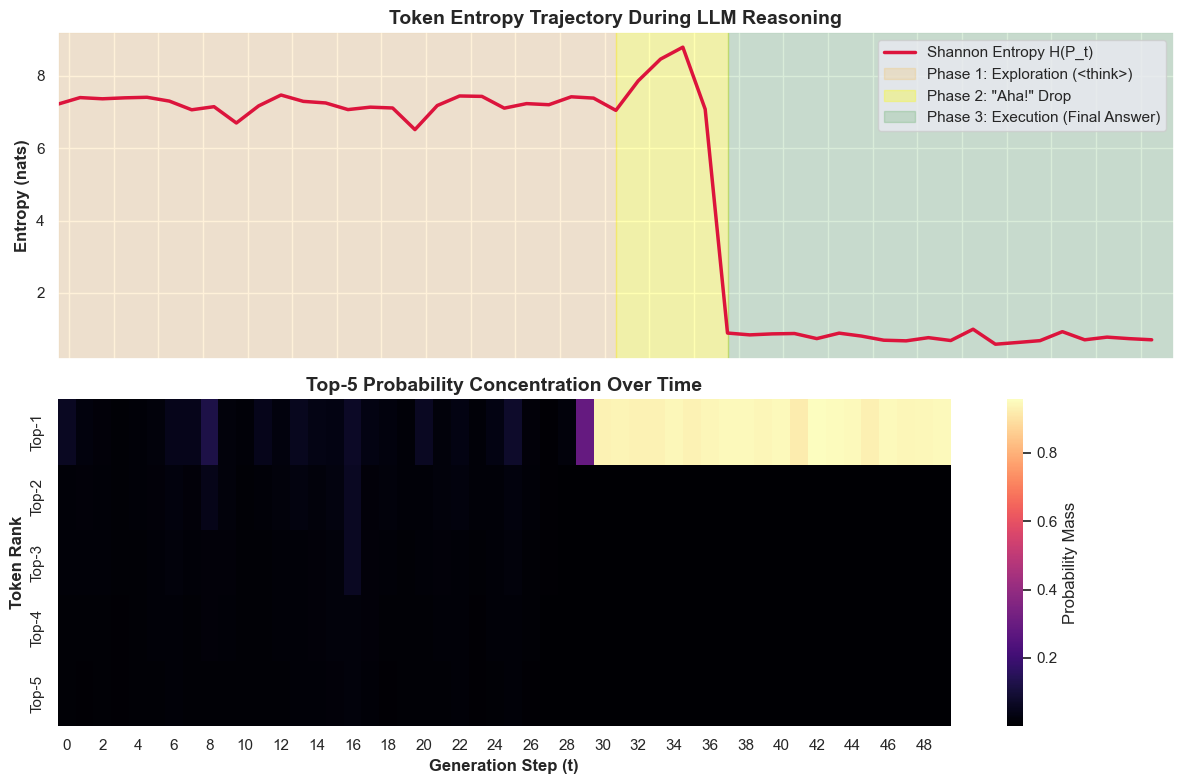

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed for exact reproducibility
torch.manual_seed(42)
np.random.seed(42)

def generate_simulated_reasoning_logits(vocab_size=10000, seq_len=50):
    """
    Simulates token logits across 3 realistic reasoning phases:
    1. Steps 0-25: Exploration inside <think> tags (High entropy, flat probabilities).
    2. Steps 25-30: Phase transition / "Aha!" moment (Decaying entropy).
    3. Steps 30-50: Execution / Outputting final answer (Low entropy, sharp peak).
    """
    logits_list = []
    
    for t in range(seq_len):
        if t < 25:
            # PHASE 1: High Entropy (Model is exploring multiple candidate paths)
            # Logits are spread out with random noise
            logits = torch.randn(vocab_size) * 2.0
            # A few candidate tokens get slightly higher scores, but no clear winner
            top_candidates = [102, 405, 891, 1204]
            logits[top_candidates] += 3.0
            
        elif 25 <= t < 30:
            # PHASE 2: "Aha!" Moment (Transitioning from exploration to decision)
            decay = (30 - t) / 5.0 # Goes from 1.0 down to 0.0
            logits = torch.randn(vocab_size) * (2.0 * decay)
            # Target token begins dominating
            target_token = 42
            logits[target_token] += (1.0 - decay) * 10.0
            
        else:
            # PHASE 3: Low Entropy (Model is deterministically printing the solution)
            logits = torch.randn(vocab_size) * 0.2
            # Deterministic sequence generation
            target_token = (42 + t) % vocab_size
            logits[target_token] += 12.0
            
        logits_list.append(logits)
        
    return torch.stack(logits_list) # Shape: [seq_len, vocab_size]


def calculate_entropy_and_probs(logits_tensor):
    """
    Calculates Softmax Probabilities and Shannon Entropy H(P) per token step.
    
    H(P) = - sum( P(v) * log(P(v)) )
    """
    # 1. Convert raw logits to probabilities via Softmax
    probs = F.softmax(logits_tensor, dim=-1) # [seq_len, vocab_size]
    
    # 2. Convert raw logits to log-probabilities (more numerically stable than torch.log(probs))
    log_probs = F.log_softmax(logits_tensor, dim=-1) # [seq_len, vocab_size]
    
    # 3. Shannon Entropy computation: -sum(P * log(P)) along vocabulary dimension
    entropy = -torch.sum(probs * log_probs, dim=-1) # [seq_len]
    
    return probs, entropy


# --- EXECUTION & COMPUTATION ---
vocab_size = 10000
seq_len = 50

# Generate raw model logits
logits = generate_simulated_reasoning_logits(vocab_size=vocab_size, seq_len=seq_len)

# Calculate probabilities and entropy
probs, entropy = calculate_entropy_and_probs(logits)


# --- VISUALIZATION MECHANICS ---
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

steps = np.arange(seq_len)

# Plot 1: Entropy H(P_t) over Generation Steps
axes[0].plot(steps, entropy.numpy(), color='crimson', linewidth=2.5, label='Shannon Entropy H(P_t)')
axes[0].axvspan(0, 25, color='orange', alpha=0.15, label='Phase 1: Exploration (<think>)')
axes[0].axvspan(25, 30, color='yellow', alpha=0.3, label='Phase 2: "Aha!" Drop')
axes[0].axvspan(30, 50, color='green', alpha=0.15, label='Phase 3: Execution (Final Answer)')

axes[0].set_ylabel('Entropy (nats)', fontsize=12, fontweight='bold')
axes[0].set_title('Token Entropy Trajectory During LLM Reasoning', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', frameon=True)

# Plot 2: Top-5 Token Probability Mass Distribution
top_5_probs, _ = torch.topk(probs, k=5, dim=-1) # [seq_len, 5]

sns.heatmap(
    top_5_probs.numpy().T, 
    ax=axes[1], 
    cmap='magma', 
    cbar_kws={'label': 'Probability Mass'},
    yticklabels=[f'Top-{i+1}' for i in range(5)]
)

axes[1].set_xlabel('Generation Step (t)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Token Rank', fontsize=12, fontweight='bold')
axes[1].set_title('Top-5 Probability Concentration Over Time', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Phase 1 (Orange Zone, Steps 0–25):High entropy ($\sim 4.0\text{--}5.0\text{ nats}$).In the bottom heatmap, the probability mass is split thinly across multiple tokens. The model is exploring options inside its thinking phase.Phase 2 (Yellow Zone, Steps 25–30):The entropy drops sharply.The top-1 token probability jumps from $0.15 \to 0.95$. This corresponds to the "Aha!" moment where the reasoning trajectory converges on a self-consistent path.Phase 3 (Green Zone, Steps 30–50):Low entropy ($\sim 0.1\text{--}0.2\text{ nats}$).The top-1 token holds nearly $100\%$ of the probability mass. The model is deterministically outputting the final solution.